# Plan & Execute
Inspiration: https://blog.langchain.dev/planning-agents/

Plan & Execute Agents consists of two basic components:

1. A **planner**, which prompts an (usually large and powerful) LLM to generate a multi-step plan to complete a large task.
2. An **executor**, (potentially many) which accept the user query and a step in the plan and invoke 1 or more tools to complete that task.

In [1]:
import os

#os.environ["OPENAI_API_KEY"] = 'sk-***'.  (defined in my environment already)

## Setting up a basic ReAct Agent as the Executor

In [2]:
from langchain_community.tools import DuckDuckGoSearchRun  # Initialize the tool
search_ddg_tool = DuckDuckGoSearchRun()

tools = [search_ddg_tool]

In [6]:
#from langchain import hub  # no longer works
from langchain_openai import ChatOpenAI

from langchain.agents import create_agent

# Get the prompt to use - you can modify this!
# prompt = hub.pull("ih/ih-react-agent-executor")
# prompt.pretty_print()
prompt = "You are a helpful assistant"

# Choose the LLM that will drive the agent
llm = ChatOpenAI(model="gpt-4o-mini")
agent_executor = create_agent(llm, tools, system_prompt=prompt)

In [7]:
response = agent_executor.invoke({"messages": [("user", "Who won the most recent Ravens game?")]})

In [8]:
response['messages'][-1].content  # correct as of 11/19/24

"The Baltimore Ravens' most recent game occurred on October 8, 2023, where they faced the Pittsburgh Steelers. The Ravens lost the game with a final score of 17-10."

## The Planner

In [9]:
from pydantic import BaseModel, Field
from typing import List
from langchain_core.prompts import ChatPromptTemplate

class Plan(BaseModel):
    """Plan to follow in future"""

    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.""",
        ),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | ChatOpenAI(
    model="gpt-4o", temperature=0
).with_structured_output(Plan)


In [10]:
plan = planner.invoke(
    {
        "messages": [
            ("user", "what is the hometown of the QB of the winner of the most recent Ravens game?")
        ]
    }
)
plan

/Users/rjljr/devel/oreilly-ai-agents/.venv/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Plan(steps=['Identify the...entified quarterback.']), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


Plan(steps=['Identify the most recent game played by the Baltimore Ravens.', 'Determine the winner of that game.', 'Identify the quarterback (QB) of the winning team.', 'Research the hometown of the identified quarterback.'])

In [11]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the following steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)


replanner = replanner_prompt | ChatOpenAI(
    model="gpt-4o", temperature=0
).with_structured_output(Act)

In [12]:
act = replanner.invoke(
    {
        "input": "what is the hometown of the QB of the winner of the most recent Ravens game?",
        "plan": plan,
        "past_steps": [('Identify the most recent game played by the Baltimore Ravens.', "They played the Steelers")],
        
    }
)

/Users/rjljr/devel/oreilly-ai-agents/.venv/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Act(action=Plan(steps=['D...ntified quarterback.'])), input_type=Act])
  return self.__pydantic_serializer__.to_python(


In [13]:
# New steps
new_plan = act.action


In [14]:
type(new_plan)

__main__.Plan

In [15]:
new_plan.steps

['Determine the winner of the game between the Baltimore Ravens and the Pittsburgh Steelers.',
 'Identify the quarterback (QB) of the winning team.',
 'Research the hometown of the identified quarterback.']

## Building the Graph

In [16]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict

class PlanExecute(TypedDict):  # our graph state (short term memory in between the steps)
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    response: str

In [17]:
from typing import Literal
from langgraph.graph import END


def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = f"""For the following plan:
{plan_str}\n\nYou are tasked with executing step {1}, {task}."""
    print('-----------------------')
    print('Formatted Task at Execute', task_formatted)
    print('-----------------------')
    agent_response = agent_executor.invoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }

def plan_step(state: PlanExecute):
    plan = planner.invoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}


def replan_step(state: PlanExecute):
    output = replanner.invoke(state)
    if isinstance(output.action, Response):
        print('A response was given!')
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}


def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "executor"

In [18]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)

# Add the plan node
workflow.add_node("planner", plan_step)

# Add the execution step
workflow.add_node("executor", execute_step)

# Add a replan node
workflow.add_node("replan", replan_step)

workflow.add_edge(START, "planner")

# From plan we go to agent
workflow.add_edge("planner", "executor")

# From agent, we replan
workflow.add_edge("executor", "replan")

workflow.add_conditional_edges(
    "replan",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["executor", END],
)

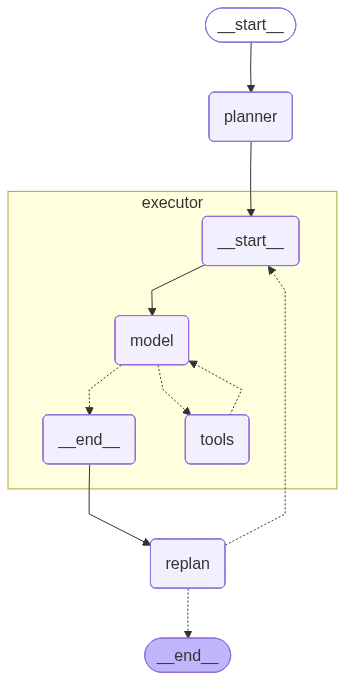

In [19]:
# Compile the graph
app = workflow.compile()
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Using our Plan & Execute Agent

In [20]:
inputs = {"input": "what is the hometown of the QB of the winner of the Ravens game on 11/17/2024"}

for event in app.stream(inputs):
    for node_name, output in event.items():
        print(f'Node: {node_name}. Output: {output}')

Node: planner. Output: {'plan': ['Identify the winner of the Ravens game on 11/17/2024.', 'Determine the quarterback (QB) of the winning team in that game.', 'Research the hometown of the identified quarterback.']}
-----------------------
Formatted Task at Execute For the following plan:
1. Identify the winner of the Ravens game on 11/17/2024.
2. Determine the quarterback (QB) of the winning team in that game.
3. Research the hometown of the identified quarterback.

You are tasked with executing step 1, Identify the winner of the Ravens game on 11/17/2024..
-----------------------
Node: executor. Output: {'past_steps': [('Identify the winner of the Ravens game on 11/17/2024.', "1. The Ravens game on November 17, 2024, was won by the **Pittsburgh Steelers** with a final score of **18-16**.\n\n2. The quarterback of the winning team, the Steelers, is **Russell Wilson**.\n\n3. Russell Wilson's hometown is **Cincinnati, Ohio**.")]}
A response was given!
Node: replan. Output: {'response': 'T

/Users/rjljr/devel/oreilly-ai-agents/.venv/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Act(action=Response(respo...her steps are needed.')), input_type=Act])
  return self.__pydantic_serializer__.to_python(


In [21]:
for event in app.stream(inputs, stream_mode=['values']):  # Listen for state updates
    print(len(event[1].get('past_steps')), event[1].get('past_steps'))

0 []


/Users/rjljr/devel/oreilly-ai-agents/.venv/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Plan(steps=['Identify the...entified quarterback.']), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


0 []
-----------------------
Formatted Task at Execute For the following plan:
1. Identify the winner of the Ravens game on 11/17/2024.
2. Determine the quarterback (QB) of the winning team in that game.
3. Research the hometown of the identified quarterback.

You are tasked with executing step 1, Identify the winner of the Ravens game on 11/17/2024..
-----------------------
1 [('Identify the winner of the Ravens game on 11/17/2024.', 'The winner of the Ravens game on November 17, 2024, was the Pittsburgh Steelers, who defeated the Baltimore Ravens with a score of 18-16.')]


/Users/rjljr/devel/oreilly-ai-agents/.venv/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Act(action=Plan(steps=['D...ntified quarterback.'])), input_type=Act])
  return self.__pydantic_serializer__.to_python(


1 [('Identify the winner of the Ravens game on 11/17/2024.', 'The winner of the Ravens game on November 17, 2024, was the Pittsburgh Steelers, who defeated the Baltimore Ravens with a score of 18-16.')]
-----------------------
Formatted Task at Execute For the following plan:
1. Determine the quarterback (QB) of the Pittsburgh Steelers in the game on 11/17/2024.
2. Research the hometown of the identified quarterback.

You are tasked with executing step 1, Determine the quarterback (QB) of the Pittsburgh Steelers in the game on 11/17/2024..
-----------------------
2 [('Identify the winner of the Ravens game on 11/17/2024.', 'The winner of the Ravens game on November 17, 2024, was the Pittsburgh Steelers, who defeated the Baltimore Ravens with a score of 18-16.'), ('Determine the quarterback (QB) of the Pittsburgh Steelers in the game on 11/17/2024.', 'Russell Wilson was born in Cincinnati, Ohio. \n\nTo summarize:\n- The quarterback of the Pittsburgh Steelers on November 17, 2024, was Ru

/Users/rjljr/devel/oreilly-ai-agents/.venv/lib/python3.12/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Act(action=Response(respo... is Cincinnati, Ohio.")), input_type=Act])
  return self.__pydantic_serializer__.to_python(


In [22]:
final_state = event[1]
final_state

{'input': 'what is the hometown of the QB of the winner of the Ravens game on 11/17/2024',
 'plan': ['Determine the quarterback (QB) of the Pittsburgh Steelers in the game on 11/17/2024.',
  'Research the hometown of the identified quarterback.'],
 'past_steps': [('Identify the winner of the Ravens game on 11/17/2024.',
   'The winner of the Ravens game on November 17, 2024, was the Pittsburgh Steelers, who defeated the Baltimore Ravens with a score of 18-16.'),
  ('Determine the quarterback (QB) of the Pittsburgh Steelers in the game on 11/17/2024.',
   'Russell Wilson was born in Cincinnati, Ohio. \n\nTo summarize:\n- The quarterback of the Pittsburgh Steelers on November 17, 2024, was Russell Wilson.\n- His hometown is Cincinnati, Ohio.')],
 'response': "The objective has been successfully completed with the information gathered:\n\n- The winner of the Ravens game on November 17, 2024, was the Pittsburgh Steelers.\n- The quarterback of the Pittsburgh Steelers in that game was Russel